In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import os
from collections import Counter

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Final_Dataset/Sam_final_dataset/Video/genuine_face_metadata_fixed.csv")

print("===== BASIC INFO =====")
print(df.info())
print("\nTotal Samples:", len(df))

===== BASIC INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   participant_id   118 non-null    object
 1   source_identity  118 non-null    object
 2   attack_type      118 non-null    object
 3   file_path        118 non-null    object
 4   label            118 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 4.7+ KB
None

Total Samples: 118


Structural Checks

In [4]:
print("\n===== STRUCTURAL CHECKS =====")

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
duplicate_rows = df.duplicated().sum()
print("\nDuplicate Rows:", duplicate_rows)


===== STRUCTURAL CHECKS =====

Missing Values:
participant_id     0
source_identity    0
attack_type        0
file_path          0
label              0
dtype: int64

Duplicate Rows: 1


Label Consistency Checks

In [5]:
# -------------------------------
# 2. LABEL CONSISTENCY CHECKS
# -------------------------------
print("\n===== LABEL CONSISTENCY =====")

# Unique values
print("Unique attack_type:", df['attack_type'].unique())
print("Unique labels:", df['label'].unique())

# Check mismatches
invalid_attack_type = df[df['attack_type'] != 'genuine']
invalid_label = df[df['label'] != 0]
identity_mismatch = df[df['participant_id'] != df['source_identity']]

print("\nInvalid attack_type rows:", len(invalid_attack_type))
print("Invalid label rows:", len(invalid_label))
print("Identity mismatches:", len(identity_mismatch))


===== LABEL CONSISTENCY =====
Unique attack_type: ['genuine']
Unique labels: [0]

Invalid attack_type rows: 0
Invalid label rows: 0
Identity mismatches: 0


File Validation

In [6]:
print("\n===== FILE VALIDATION =====")

missing_files = []
for path in df['file_path']:
    if not os.path.exists(path):
        missing_files.append(path)

print("Missing files:", len(missing_files))

# Optional: print first few missing
print("Sample missing files:", missing_files[:5])


===== FILE VALIDATION =====
Missing files: 0
Sample missing files: []


Duplicate File Detection

In [7]:
print("\n===== DUPLICATE FILE CHECK =====")

duplicate_files = df['file_path'].duplicated().sum()
print("Duplicate file paths:", duplicate_files)



===== DUPLICATE FILE CHECK =====
Duplicate file paths: 1


Distribution Analysis

In [8]:
print("\n===== DISTRIBUTION ANALYSIS =====")

# Participants
unique_participants = df['participant_id'].nunique()
print("Unique participants:", unique_participants)

# Samples per participant
participant_counts = df['participant_id'].value_counts()

print("\nTop 5 participants by sample count:")
print(participant_counts.head())

print("\nMin samples per participant:", participant_counts.min())
print("Max samples per participant:", participant_counts.max())
print("Mean samples per participant:", participant_counts.mean())


===== DISTRIBUTION ANALYSIS =====
Unique participants: 98

Top 5 participants by sample count:
participant_id
P074    5
P066    5
P065    3
P072    3
P067    2
Name: count, dtype: int64

Min samples per participant: 1
Max samples per participant: 5
Mean samples per participant: 1.2040816326530612


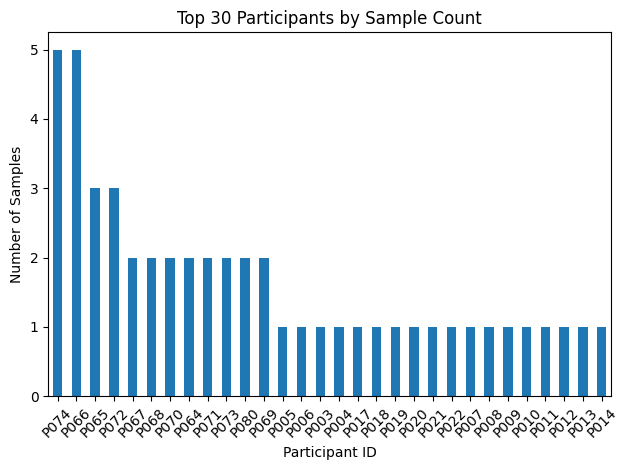

In [13]:
import matplotlib.pyplot as plt

# -------------------------------
# PARTICIPANT DISTRIBUTION
# -------------------------------
participant_counts = df['participant_id'].value_counts()

plt.figure()
participant_counts.head(30).plot(kind='bar')
plt.title("Top 30 Participants by Sample Count")
plt.xlabel("Participant ID")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

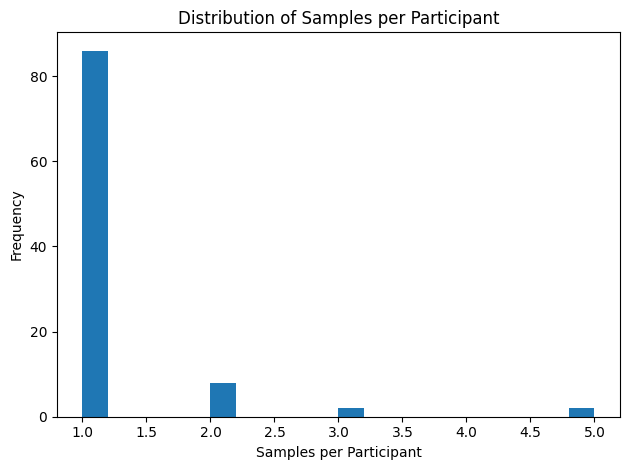

In [15]:
# -------------------------------
# HISTOGRAM (DATA DISTRIBUTION)
# -------------------------------
plt.figure()
participant_counts.plot(kind='hist', bins=20)
plt.title("Distribution of Samples per Participant")
plt.xlabel("Samples per Participant")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

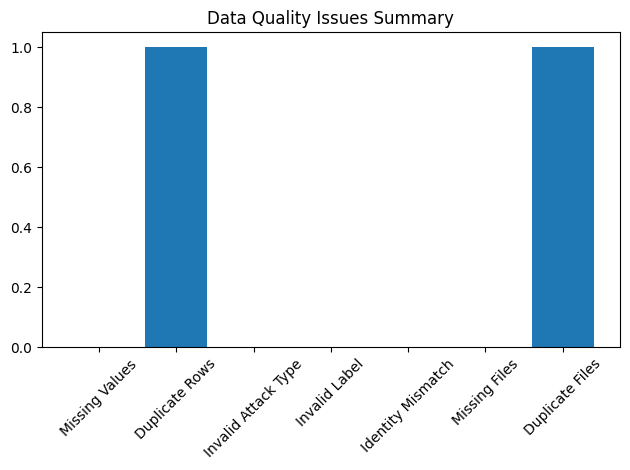

In [16]:
# -------------------------------
# DATA QUALITY SUMMARY
# -------------------------------
labels = [
    "Missing Values",
    "Duplicate Rows",
    "Invalid Attack Type",
    "Invalid Label",
    "Identity Mismatch",
    "Missing Files",
    "Duplicate Files"
]

values = [
    df.isnull().sum().sum(),
    duplicate_rows,
    len(invalid_attack_type),
    len(invalid_label),
    len(identity_mismatch),
    len(missing_files),
    duplicate_files
]

plt.figure()
plt.bar(labels, values)
plt.title("Data Quality Issues Summary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Final Summary

In [17]:
print("\n===== FINAL SUMMARY =====")

issues = {
    "missing_values": df.isnull().sum().sum(),
    "duplicate_rows": duplicate_rows,
    "invalid_attack_type": len(invalid_attack_type),
    "invalid_label": len(invalid_label),
    "identity_mismatch": len(identity_mismatch),
    "missing_files": len(missing_files),
    "duplicate_files": duplicate_files
}

print(issues)


===== FINAL SUMMARY =====
{'missing_values': np.int64(0), 'duplicate_rows': np.int64(1), 'invalid_attack_type': 0, 'invalid_label': 0, 'identity_mismatch': 0, 'missing_files': 0, 'duplicate_files': np.int64(1)}


SECTION 1: DATASET OVERVIEW

Dataset Shape: (118, 5)

Columns: ['participant_id', 'source_identity', 'attack_type', 'file_path', 'label']

First 5 Rows:


,participant_id,source_identity,attack_type,file_path,label
0,P001,P001,genuine,/content/drive/MyDrive/Final_Dataset/Sam_final...,0
1,P002,P002,genuine,/content/drive/MyDrive/Final_Dataset/Sam_final...,0
2,P003,P003,genuine,/content/drive/MyDrive/Final_Dataset/Sam_final...,0
3,P004,P004,genuine,/content/drive/MyDrive/Final_Dataset/Sam_final...,0
4,P005,P005,genuine,/content/drive/MyDrive/Final_Dataset/Sam_final...,0



Data Types:
participant_id     object
source_identity    object
attack_type        object
file_path          object
label               int64
dtype: object

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   participant_id   118 non-null    object
 1   source_identity  118 non-null    object
 2   attack_type      118 non-null    object
 3   file_path        118 non-null    object
 4   label            118 non-null    int64 
dtypes: int64(1), object(4)
memory usage: 4.7+ KB
None

SECTION 2: INTEGRITY CHECKS

Missing Values Per Column:
participant_id     0
source_identity    0
attack_type        0
file_path          0
label              0
dtype: int64

Duplicate Rows: 1
Duplicate File Paths: 1

Invalid attack_type rows: 0
Invalid label rows: 0
Identity mismatch rows: 0

Missing Files: 0

SECTION 3: MODALITY-SPECIFIC VIDEO VALIDAT

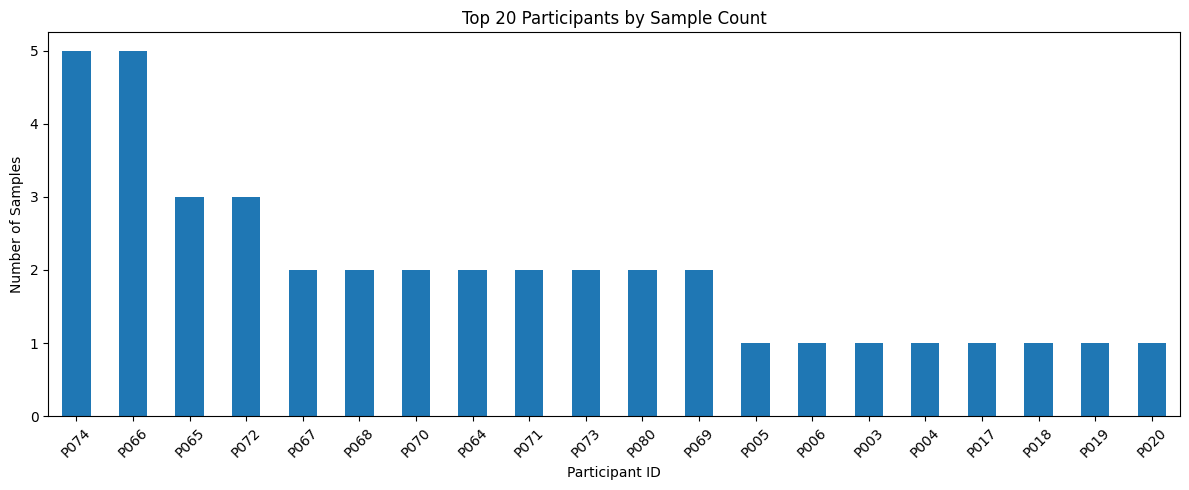

Interpretation:
This plot shows whether the dataset is dominated by a small number of participants.
A relatively even spread suggests lower participant bias, while sharp peaks indicate overrepresentation.



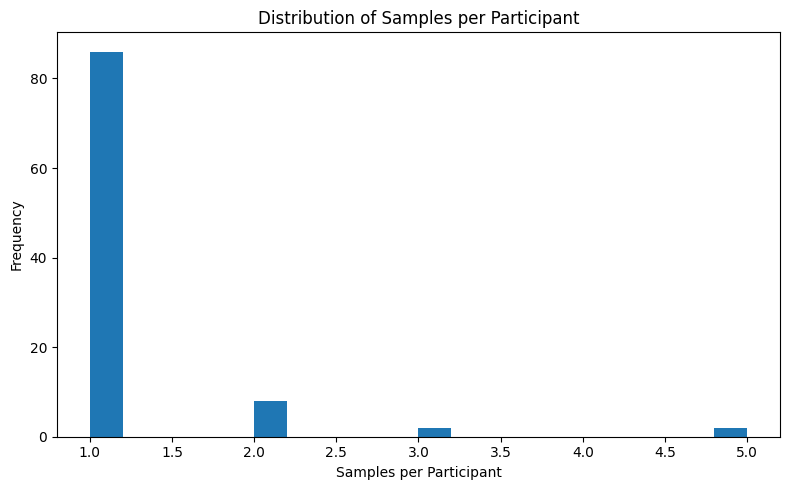

Interpretation:
This histogram summarizes how evenly samples are distributed across participants.
A narrow distribution indicates consistency, while a wide spread suggests imbalance.



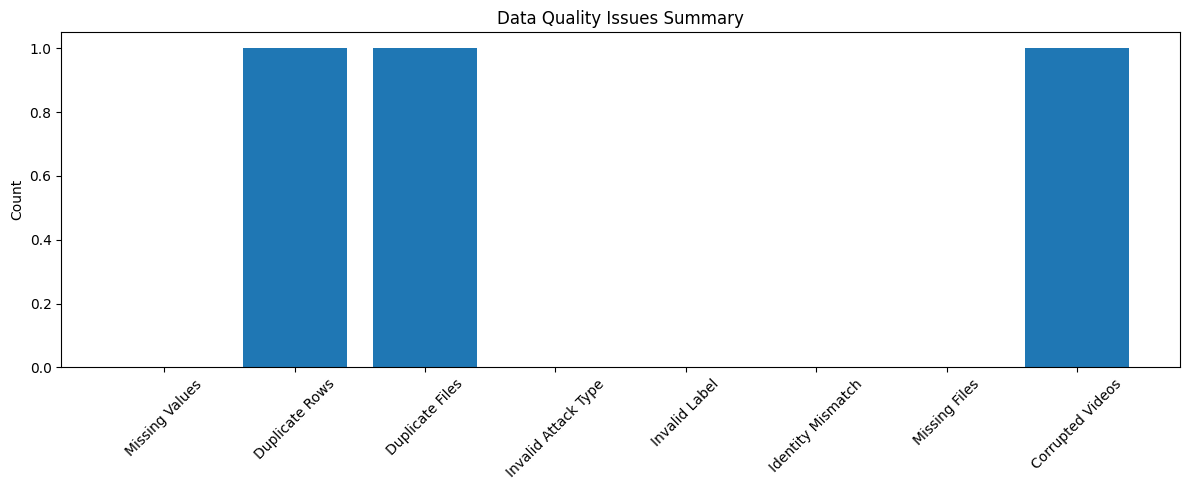

Interpretation:
This plot provides a compact summary of structural and file-level issues.
Ideally, all bars should be zero or near zero for a clean dataset.



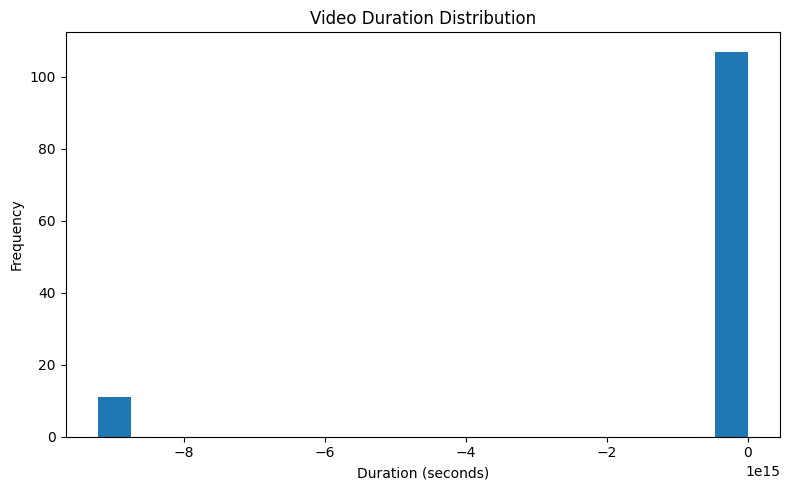

Interpretation:
This plot shows whether video durations are consistent across genuine samples.
Large variation may indicate inconsistent recording conditions or preprocessing differences.


SECTION 7: INTERPRETATION BLOCK

Structural Integrity: The dataset contains structural issues that should be cleaned before further use.
Label Consistency: All samples are correctly marked as genuine with label 0.
Identity Consistency: participant_id and source_identity are fully aligned, which is expected for bona fide samples.
File Availability: All referenced files are present.
Video Quality: Some videos are corrupted, unreadable, or invalid, and should be removed or repaired.
Participant Distribution: Mild participant imbalance is present but may still be acceptable.

SECTION 8: FINAL ASSESSMENT
The genuine dataset is largely usable, but minor issues were detected. These should be cleaned before final model training and evaluation.


In [18]:
import pandas as pd
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# SECTION 1: DATASET OVERVIEW
# =========================================================

csv_path = "/content/drive/MyDrive/Final_Dataset/Sam_final_dataset/Video/genuine_face_metadata_fixed.csv"
df = pd.read_csv(csv_path)

print("=" * 70)
print("SECTION 1: DATASET OVERVIEW")
print("=" * 70)

print("\nDataset Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Info:")
print(df.info())

# =========================================================
# SECTION 2: INTEGRITY CHECKS
# =========================================================

print("\n" + "=" * 70)
print("SECTION 2: INTEGRITY CHECKS")
print("=" * 70)

# Missing values
missing_values = df.isnull().sum()

print("\nMissing Values Per Column:")
print(missing_values)

# Duplicate rows
duplicate_rows = df.duplicated().sum()
print("\nDuplicate Rows:", duplicate_rows)

# Duplicate file paths
duplicate_files = df["file_path"].duplicated().sum()
print("Duplicate File Paths:", duplicate_files)

# Label consistency
invalid_attack_type = df[df["attack_type"] != "genuine"]
invalid_label = df[df["label"] != 0]
identity_mismatch = df[df["participant_id"] != df["source_identity"]]

print("\nInvalid attack_type rows:", len(invalid_attack_type))
print("Invalid label rows:", len(invalid_label))
print("Identity mismatch rows:", len(identity_mismatch))

# Missing files
missing_files = []
existing_files = []

for path in df["file_path"]:
    if os.path.exists(path):
        existing_files.append(path)
    else:
        missing_files.append(path)

print("\nMissing Files:", len(missing_files))
if len(missing_files) > 0:
    print("Sample Missing Files:")
    print(missing_files[:5])

# =========================================================
# SECTION 3: MODALITY-SPECIFIC VIDEO VALIDATION
# =========================================================

print("\n" + "=" * 70)
print("SECTION 3: MODALITY-SPECIFIC VIDEO VALIDATION")
print("=" * 70)

video_stats = []
corrupted_videos = []
zero_frame_videos = []
zero_fps_videos = []
zero_duration_videos = []

for path in existing_files:
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        corrupted_videos.append(path)
        continue

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps is None or fps <= 0:
        duration = 0
        zero_fps_videos.append(path)
    else:
        duration = frame_count / fps

    ret, frame = cap.read()

    if frame_count == 0:
        zero_frame_videos.append(path)

    if duration == 0:
        zero_duration_videos.append(path)

    readable = ret and frame is not None

    if not readable:
        corrupted_videos.append(path)

    video_stats.append({
        "file_path": path,
        "frame_count": frame_count,
        "fps": fps,
        "duration_sec": duration,
        "readable_first_frame": readable
    })

    cap.release()

video_stats_df = pd.DataFrame(video_stats)

print("\nTotal Existing Videos Checked:", len(existing_files))
print("Unreadable / Corrupted Videos:", len(set(corrupted_videos)))
print("Zero-frame Videos:", len(set(zero_frame_videos)))
print("Zero-FPS Videos:", len(set(zero_fps_videos)))
print("Zero-duration Videos:", len(set(zero_duration_videos)))

if len(corrupted_videos) > 0:
    print("\nSample Corrupted/Unreadable Videos:")
    print(list(set(corrupted_videos))[:5])

if not video_stats_df.empty:
    print("\nVideo Duration Summary (seconds):")
    print(video_stats_df["duration_sec"].describe())

    print("\nFrame Count Summary:")
    print(video_stats_df["frame_count"].describe())

    print("\nFPS Summary:")
    print(video_stats_df["fps"].describe())

# =========================================================
# SECTION 4: DISTRIBUTION ANALYSIS
# =========================================================

print("\n" + "=" * 70)
print("SECTION 4: DISTRIBUTION ANALYSIS")
print("=" * 70)

# Participant distribution
participant_counts = df["participant_id"].value_counts()

print("\nUnique Participants:", df["participant_id"].nunique())
print("Min Samples per Participant:", participant_counts.min())
print("Max Samples per Participant:", participant_counts.max())
print("Mean Samples per Participant:", participant_counts.mean())

print("\nTop 10 Participants by Sample Count:")
print(participant_counts.head(10))

# =========================================================
# SECTION 5: DATA QUALITY FINDINGS
# =========================================================

print("\n" + "=" * 70)
print("SECTION 5: DATA QUALITY FINDINGS")
print("=" * 70)

issues = {
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(duplicate_rows),
    "duplicate_files": int(duplicate_files),
    "invalid_attack_type": int(len(invalid_attack_type)),
    "invalid_label": int(len(invalid_label)),
    "identity_mismatch": int(len(identity_mismatch)),
    "missing_files": int(len(missing_files)),
    "corrupted_videos": int(len(set(corrupted_videos))),
    "zero_frame_videos": int(len(set(zero_frame_videos))),
    "zero_fps_videos": int(len(set(zero_fps_videos))),
    "zero_duration_videos": int(len(set(zero_duration_videos)))
}

print("\nIssues Summary:")
for k, v in issues.items():
    print(f"{k}: {v}")

# =========================================================
# SECTION 6: VISUALIZATIONS
# =========================================================

print("\n" + "=" * 70)
print("SECTION 6: VISUALIZATIONS")
print("=" * 70)

# ---------- Plot 1: Top participants ----------
plt.figure(figsize=(12, 5))
participant_counts.head(20).plot(kind="bar")
plt.title("Top 20 Participants by Sample Count")
plt.xlabel("Participant ID")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("This plot shows whether the dataset is dominated by a small number of participants.")
print("A relatively even spread suggests lower participant bias, while sharp peaks indicate overrepresentation.\n")

# ---------- Plot 2: Histogram of samples per participant ----------
plt.figure(figsize=(8, 5))
participant_counts.plot(kind="hist", bins=20)
plt.title("Distribution of Samples per Participant")
plt.xlabel("Samples per Participant")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Interpretation:")
print("This histogram summarizes how evenly samples are distributed across participants.")
print("A narrow distribution indicates consistency, while a wide spread suggests imbalance.\n")

# ---------- Plot 3: Data quality summary ----------
quality_labels = [
    "Missing Values",
    "Duplicate Rows",
    "Duplicate Files",
    "Invalid Attack Type",
    "Invalid Label",
    "Identity Mismatch",
    "Missing Files",
    "Corrupted Videos"
]

quality_values = [
    issues["missing_values_total"],
    issues["duplicate_rows"],
    issues["duplicate_files"],
    issues["invalid_attack_type"],
    issues["invalid_label"],
    issues["identity_mismatch"],
    issues["missing_files"],
    issues["corrupted_videos"]
]

plt.figure(figsize=(12, 5))
plt.bar(quality_labels, quality_values)
plt.title("Data Quality Issues Summary")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("This plot provides a compact summary of structural and file-level issues.")
print("Ideally, all bars should be zero or near zero for a clean dataset.\n")

# ---------- Plot 4: Video duration distribution ----------
if not video_stats_df.empty:
    plt.figure(figsize=(8, 5))
    plt.hist(video_stats_df["duration_sec"], bins=20)
    plt.title("Video Duration Distribution")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    print("Interpretation:")
    print("This plot shows whether video durations are consistent across genuine samples.")
    print("Large variation may indicate inconsistent recording conditions or preprocessing differences.\n")

# =========================================================
# SECTION 7: INTERPRETATION BLOCK
# =========================================================

print("\n" + "=" * 70)
print("SECTION 7: INTERPRETATION BLOCK")
print("=" * 70)

# Structural interpretation
if issues["missing_values_total"] == 0 and issues["duplicate_rows"] == 0 and issues["duplicate_files"] == 0:
    print("\nStructural Integrity: The dataset is structurally clean, with no missing values or duplicate records detected.")
else:
    print("\nStructural Integrity: The dataset contains structural issues that should be cleaned before further use.")

# Label interpretation
if issues["invalid_attack_type"] == 0 and issues["invalid_label"] == 0:
    print("Label Consistency: All samples are correctly marked as genuine with label 0.")
else:
    print("Label Consistency: Label inconsistencies were detected, indicating possible contamination or annotation errors.")

# Identity interpretation
if issues["identity_mismatch"] == 0:
    print("Identity Consistency: participant_id and source_identity are fully aligned, which is expected for bona fide samples.")
else:
    print("Identity Consistency: Identity mismatches were found, which is a critical issue for a genuine dataset.")

# File interpretation
if issues["missing_files"] == 0:
    print("File Availability: All referenced files are present.")
else:
    print("File Availability: Some referenced files are missing, reducing dataset completeness.")

# Video interpretation
if issues["corrupted_videos"] == 0 and issues["zero_frame_videos"] == 0 and issues["zero_duration_videos"] == 0:
    print("Video Quality: All checked videos appear readable and valid for further processing.")
else:
    print("Video Quality: Some videos are corrupted, unreadable, or invalid, and should be removed or repaired.")

# Participant distribution interpretation
max_count = participant_counts.max()
mean_count = participant_counts.mean()

if max_count <= 2 * mean_count:
    print("Participant Distribution: The dataset appears reasonably balanced across participants.")
elif max_count <= 5 * mean_count:
    print("Participant Distribution: Mild participant imbalance is present but may still be acceptable.")
else:
    print("Participant Distribution: Strong participant imbalance detected; this may bias training.")

# =========================================================
# SECTION 8: FINAL ASSESSMENT
# =========================================================

print("\n" + "=" * 70)
print("SECTION 8: FINAL ASSESSMENT")
print("=" * 70)

critical_issues = (
    issues["invalid_attack_type"] +
    issues["invalid_label"] +
    issues["identity_mismatch"] +
    issues["missing_files"] +
    issues["corrupted_videos"]
)

if critical_issues == 0:
    final_verdict = (
        "The genuine dataset is clean, internally consistent, and suitable for use as the bona fide class "
        "in training and evaluation. No critical structural, labeling, identity, or video integrity issues were detected."
    )
elif critical_issues <= 5:
    final_verdict = (
        "The genuine dataset is largely usable, but minor issues were detected. These should be cleaned before "
        "final model training and evaluation."
    )
else:
    final_verdict = (
        "The genuine dataset contains significant issues that should be resolved before it is used as the bona fide class "
        "for training and evaluation."
    )

print(final_verdict)